# Lecture 2: Fundamentals of Stochastic Differential Equations

In the last lecture we have seen how to model a system using DTMCs. \
During the analysis we have also seen has this kind of modelling can lead to some issues that can be solved only using methods with increased complexity. \
The most immediate solution is via CTMCs but we will see it after d'Onofrio has introduced the Gillespie-SSA algorithm thus we will take a look to the SDE method. \
In this lecture we will start from the logistic system and we will understand how to simulate SDE trajectories using the Euler-Maruyama method while trying to understand how to perform qualitative analysis.

In the following one we will deep down in better simulative methods and more advanced tests.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

## Exercise 1: Logistic system

In the previous lecture we tried to model a logistic system via a DTMC. \
We know already, from whatever SD course you have done, that, for sufficiently big numbers of individuals, the population size can be described by the following ODE in a deterministic scenario:

$$
\frac{dx(t)}{dt}=rx\left(1-\frac{x}{K}\right)
$$

Where the $r$ is the governing parameter that it is positive in a situation where fertility is greater than mortality. \
$K$ is on the other hand the carry capacity of the system.

Doing a little bit of deterministic qualitative analysis we are able to find that the critical points are $x_1=0$ and $x_2=K$. To study the behaviour of these critical points we can simply study the flux and we find that:

$$
rx\left(1-\frac{x}{K}\right)\geq0 \qquad\Leftrightarrow \qquad
\begin{cases}
+: 0\leq x \leq K;\quad -: x\geq K; & \text{if } r\geq 0\\
+: x\geq K; \quad -: 0\leq x \leq K; & \text{if } r<0
\end{cases}
$$

As we can notice there is still a problem. In fact for $r<0$, the behaviour for $x(t)>K$ is divergent always for $r<0$. This is actually an important limit of the logistic equation. Therefore, even if the speed problem and the normalization problem are still present, the divergence appeared in the previous lecture was quite a limit of validity of the model. Due to this we can consider the logistic system only with $r\geq0$ which tells us that we cannot describe extinctions with this model! This has actually some sense if you think about...
\
Therefore, we have no true bifurcations for our model. Having different $K$, excluding pathological values, simply moves the attractor point around the domain while the $r$ regulates the convergence speed.

Aside this, there is also another issue that will not allow us to use this model to describe extinctions. Can you spot it?

Ok we want to simulate this model. This is fairly simple. In this course I'm giving as granted and known all the fundamental about simulating deterministic differential equation at least the ordinary and/or linear ones. For the SDE, we will introduce the Euler-Maruyama algorithm thus we will use here the Euler algorithm that descend from the Finite Difference Scheme:

$$
\frac{dx(t)}{dt}=rx\left(1-\frac{x}{K}\right) \quad\Rightarrow\quad \frac{x_{n+1}-x_n}{h}=rx_n\left(1-\frac{x_n}{K}\right) \quad\Rightarrow\quad x_{n+1}=x_n+hrx_n\left(1-\frac{x_n}{K}\right)
$$

In [2]:
class DetLog(object):

    #CONSTRUCTOR:
    def __init__(self,r: float,K: float)->None:

        #Perform positivity checks
        if(r<0):
            raise RuntimeError("r must be non-negative.")
        if(K<=0):
            raise RuntimeError("K must be positive.")

        self._r = r
        self._K = K

        return

    #This function will produce a realization/trajectory for the system
    #using the Euler discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Euler method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1] + h*self._r*traj[i-1]*(1.0-traj[i-1]/self._K)

        return traj

We can now try to produce a test trajectory:

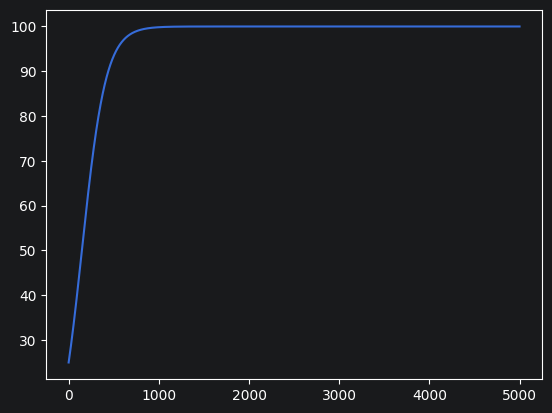

In [3]:
system = DetLog(0.75,100)

t = system.computeTraj(5000,0.01,25)

plt.plot(t)

Ok, it looks good. In this case being deterministic making the distributions as no sense at all. It is important to remember that we are using the Euler Method that a cumulative error that scales as $O(h)$. What does it means? It means that the truncation error is below $Ch$ where $C$ depends on the second order derivative. Thus Euler works well only for sufficiently regular and smooth fields. 

There is nothing to do, thus let's try to move to a stochastic version:

## Exercise 2: Stochastic Logistic system

We want now to work with a stochastic version of the model. Being $K$ only a position element we can work with $K:=r$ to simplify a bit. One possibility is to add some perturbations to the speed factor. Doing this, the system will be characterize by the following Ito equation:

$$
dx=[rx-x^2]dt+axdW
$$

which is associated to the deterministic problem where $r\rightarrow r+a\xi(t)$. Certainly there are other possibilities: one of them is to add a perturbation at the derivative level: such as

$$
dx=[rx-x^2]dt+\sigma dW
$$

but this is gravely wrong. Can you guess why? It is a common error present sometimes also in paper-grade texts....

Sticking to the first version, the only correct one between the two, we can try to perform some qualitative analysis: first of all we can try to find the critical points. Doing so can be found that:

- 0 is repulsor and $r-a^2$ is attractor in the domain if $r-a^2\geq0$
- 0 is attactor for the domain if $r-a^2\leq0$

This tells us that the noise, if it is sufficiently strong can annihilate the population. This phenomena is called *Noise Induced Extinctions* and it is part of the more general category of the *Noise Induced Transitions*. More in particular the apparition of the NIE happens via *transcritical bifurcation*.

We can also compute the probability distribution for our problem solving the associated FP equation:

$$
P_s(x)=Ax^{\frac{2r}{a^2}-2}e^{-\frac{2x}{a^2}}
$$

where this is valid when $x\neq0$. If we try to verify, it can be shown that for $r/a^2>1$ in $x=0$ the $P_s(0)\equiv 0$ but for the opposite condition it diverges. This leads to some problems now: in fact this probability distribution to be defined needs to set a correct normalization constant $A$. This can be computed only when $P_s$ is integrable and this happens when $2r/a^2>1$ however, as seen, this does not mean that outside of this region the distribution has no sense but it's simply not possible to compute the integral to obtain $A$ so we will need to set it manually or compute it using other methods and tools.

Doing a quick reminder about the *Euler-Maruyama method*, we need to know that this descend directly from the *Euler method* and it is the simplest, yet the one with bigger error, method to simulate an SDE. Given an SDE in Ito's shape:

$$
dx = f(x)dt+g(x)dW \quad\Rightarrow\quad x_{n+1}=x_n+hf(x_n)+g(x_n)\sqrt{h}\mathcal{N}(0,1)
$$

I will not show why we can simulate $dW$ in such a way. This method is not so good under the cumulative error point of view ($O(\sqrt{h})$) therefore it requires smoother fields than the standard Euler and the step must be sufficiently small.

Now we can start to code it!

In [4]:
class StoLog(object):

    #CONSTRUCTOR:
    def __init__(self,r: float,a: float)->None:
        #First let's check the inputs
        if(r<0 or a<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._r = r
        self._a = a
        return

    #This function will produce a realization/trajectory for the system
    #using the Euler-Maruyama discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.ndarray:
        '''
        Given the number of steps, the step length, and the initial condition,
        this function will produce a trajectory using the Euler-Maruyama method.
        '''

        #1. Perform some check of the arguments:
        if n_step<0:
            raise RuntimeError("The number of step must be non-negative.")
        if h<=0:
            raise RuntimeError("Step size must be positive.")
        if x0<0:
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+traj[i-1]*(self._r-traj[i-1])*h #DETERMINISTIC PART
            traj[i] += self._a*traj[i-1]*np.sqrt(h)*random.gauss(0,1)

        return traj

Let's make a test trajectory, to see if everthing works:

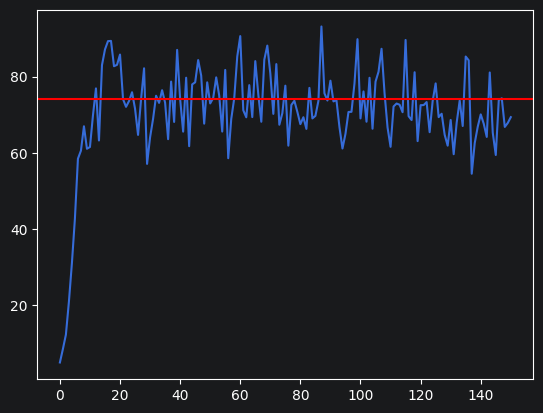

In [5]:
system = StoLog(75,1)

traj = system.computeTraj(150,0.01,5)

plt.plot(traj)
plt.axhline(74,color='r') 

It seems good and plausible. We have also to remember that our system does not converge to $r$ but to the noise corrected attractor point $r-a^2$.

Having seen that the trajectories are quite good, we can try to produce the probability distributions for the two cases. To do so we need, as in the previous lecture, to produce a bunch of trajectories with random initial value in my domain of interest and then collect the values after a sufficient long time. In this way we should be able to observe the steady state behaviour...

Let's look first for the case when $r/a^2>1$

In [6]:
#First we need to define all the binning parameters
omega = [5,25] #the domain
Nbins = 100
Nsim = 1000
k = (omega[1]-omega[0])/Nbins #bin size
system = StoLog(15,1)

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    LP = system.computeTraj(1000,0.001,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if LP<(k*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*k) #Normalization

<BarContainer object of 100 artists>

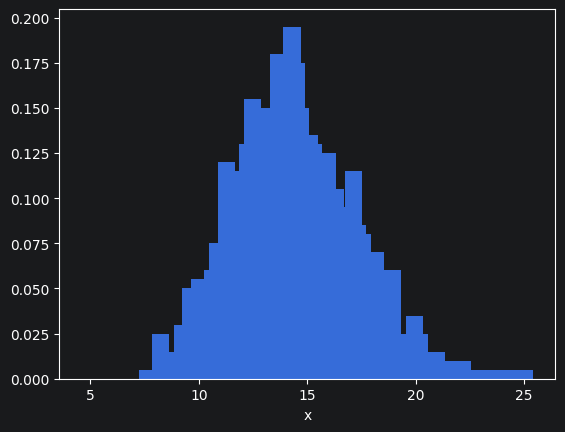

In [7]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlabel("x")

plt.bar(x,bins)

This was quite what we where expecting: a peak centered around the attractor point! We can immediately notice that this is obviously symmetric and has tails on the both side because the attractor point for the system does not grant *noise suppression*. This can also be explained in more mathematical way as: the attractor point for the system does not produce a 0 value for the stochastic component of the field.

Let's try to do the same for the other parametric condition. However, if we try to do it (try if you want) with the same parameter errors start to arise. The reason is fairly simple and it is strictly linked to that smoothness hypothesis that I asked before. Thus if I simply switch, for example, $r$ with $a$ the error will explode because with such large step the trajectories will become so negative to pass over $r-a^2$ and, after this point, they will diverge to $-\infty$ due to repulsive nature of this critical point. Usually the best solution in this case is to reduce $h$ (as I have done) but this will increase the trajectory length and with this the computation time and the RAM usage.

In [8]:
#First we need to define all the binning parameters #IT WILL REQUIRE MORE TIME FOR THE REASON SAID ABOVE (APPROX x10)
omega = [0,25] #the domain
Nbins = 100
Nsim = 1000
k = (omega[1]-omega[0])/Nbins #bin size
system = StoLog(15,10)

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    LP = system.computeTraj(10000,0.0001,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if LP<(k*(i+1)+omega[0]):
            bins[i] += 1.0
            break
            
bins = bins/(Nsim*k) #Normalization

<BarContainer object of 100 artists>

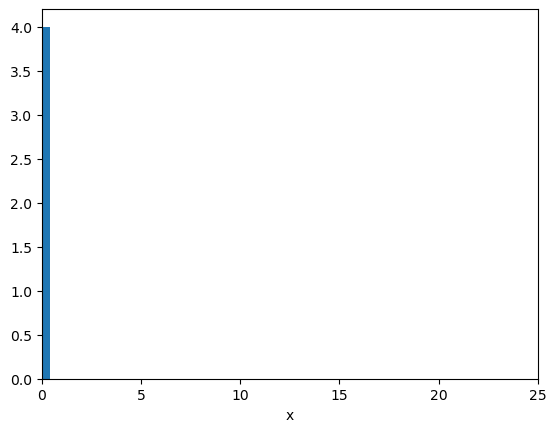

In [9]:
x = np.linspace(omega[0],omega[1],Nbins)

plt.xlabel("x")
plt.xlim(0,omega[1])
plt.bar(x,bins)

## Exercise 3: Finding the normalization constant

To conclude this lecture, I want to spend a little extra time to show you how we can compute the normalization constant for the $P_s$ found via the Fokker-Plank equation. In fact, it would be very nice to try to fit the solution of the FPE we have found analytically to our simulative results (at least for the integrable situation) but, to do this, we need to find the normalization constant $A$. 

NOTE: some of you should/could already have done the following method during some Numerical Analysis courses

To find the normalization constant, we need to integrate the probability distribution for our set of parameters. In the system, we have analyzed previously it is possible to find the integral and it even have an pseudo-analytical form (composed by a Gamma function) but most of the time the resulting $P_s(x)$ are so complex to not have a clear, or trivially findable, analytical form. Therefore to integrate it we need some kind of method...

To integrate a function there are several ways and they have different order of magnitude in their error. Not having a very good error in the simulation of the trajectory using the *trapezoidal rule* will be ok. To apply this rule we need to define first a grid along $x$ ($x_k\in\{x_0,...,x_K\}$) and then

$$
I_x(P_s(x))\approx\sum_{k=0}^{K-1}\frac{P_s(x_{k+1})-P_s(x_k)}{2}\Delta_{x_k}
$$

where $\Delta_{x_k}$ is the length of the step between $x_k$ and $x_{k+1}$. 

In [9]:
#Let's define P first for the set of parameters:

r = 15
a = 1

P = lambda x: np.power(x,2*(r/(a*a))-2)*np.exp(-2*x/(a*a))

#Now lets make the grid and the step:
x = np.linspace(0,25,1000)
delta = x[1]-x[0] #in this case is constant

A = 0.0
for i in range(len(x)-1):
    A += delta*(P(x[i])+P(x[i+1]))/2

print(A)

5.6760886596191224e+20


Perfect! Now we can try to fit!

In [10]:
#First we need to define all the binning parameters
omega = [5,25] #the domain
Nbins = 100
Nsim = 1000
k = (omega[1]-omega[0])/Nbins #bin size
system = StoLog(15,1)

bins = np.zeros(Nbins,dtype=float)

for _ in range(Nsim):
    LP = system.computeTraj(1000,0.001,random.uniform(omega[0],omega[1]))[-1]
    for i in range(Nbins):
        if LP<(k*(i+1)+omega[0]):
            bins[i] += 1.0
            break

bins = bins/(Nsim*k) #Normalization

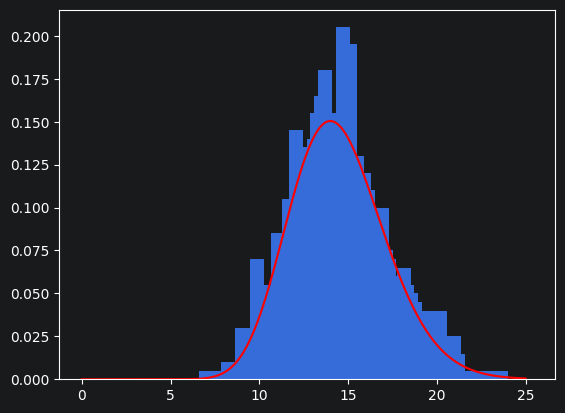

In [12]:
P = lambda x: np.power(x,2*(r/(a*a))-2)*np.exp(-2*x/(a*a))/A

prob_dist = P(x)
b = np.linspace(omega[0],omega[1],Nbins)

plt.bar(b,bins)
plt.plot(x,prob_dist,color='r')